# Injection Molding Defect Classification using Random Forest and XGBoost

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [2]:
# Load the dataset

df = pd.read_csv("timeseries_features.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (564, 1416)


,DOS_acBatchCounter_mean,DOS_acBatchCounter_std,DOS_acBatchCounter_min,DOS_acBatchCounter_max,DOS_acBatchCounter_range,DOS_acBatchCounter_median,DOS_acBatchCounter_skew,DOS_acBatchCounter_kurtosis,DOS_acBatchCounter_energy,DOS_acBatchCounter_rms,...,TCN_TemperatureReturnLine_rms,TCN_TemperatureReturnLine_peak,LBL_NOK,LBL_OldGranulate,LBL_SinkMarks,LBL_SprueCircle,LBL_StreaksLevel1,LBL_StreaksLevel2,LBL_StreaksLevel3,LBL_Underfilled
0,190.740741,0.438228,190.0,191.0,1.0,191.0,-1.098701,-0.792857,982320.0,190.741244,...,20.3,20.3,1,0.0,1,0,0,0,0,0
1,191.000000,0.000000,191.0,191.0,0.0,191.0,0.000000,0.000000,984987.0,191.000000,...,20.3,20.3,1,0.0,1,0,0,0,0,0
2,191.000000,0.000000,191.0,191.0,0.0,191.0,0.000000,0.000000,1057949.0,191.000000,...,20.3,20.3,1,0.0,1,0,0,0,0,0
3,191.000000,0.000000,191.0,191.0,0.0,191.0,0.000000,0.000000,1021468.0,191.000000,...,20.3,20.3,1,0.0,1,0,0,0,0,0
4,191.000000,0.000000,191.0,191.0,0.0,191.0,0.000000,0.000000,1021468.0,191.000000,...,20.3,20.3,1,0.0,1,0,0,0,0,0


In [22]:
df.describe()

,DOS_acBatchCounter_mean,DOS_acBatchCounter_std,DOS_acBatchCounter_min,DOS_acBatchCounter_max,DOS_acBatchCounter_range,DOS_acBatchCounter_median,DOS_acBatchCounter_skew,DOS_acBatchCounter_kurtosis,DOS_acBatchCounter_energy,DOS_acBatchCounter_rms,...,TCN_TemperatureReturnLine_rms,TCN_TemperatureReturnLine_peak,LBL_NOK,LBL_OldGranulate,LBL_SinkMarks,LBL_SprueCircle,LBL_StreaksLevel1,LBL_StreaksLevel2,LBL_StreaksLevel3,LBL_Underfilled
count,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,4.120000e+02,412.000000,...,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000
mean,162.593498,0.054547,162.533981,162.667476,0.133495,162.583738,0.044436,0.266201,1.376081e+06,162.593544,...,35.843056,35.884976,0.269417,0.021845,0.240291,0.174757,0.029126,0.029126,0.058252,0.145631
std,133.689489,0.143677,133.642863,133.746714,0.340523,133.682768,0.729732,2.612423,1.632123e+06,133.689521,...,15.098428,15.107028,0.444197,0.146354,0.427780,0.380221,0.168365,0.168365,0.234505,0.353165
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.918364,-2.000000,0.000000e+00,0.000000,...,20.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,21.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,215.678571,0.000000,215.500000,216.000000,0.000000,215.500000,0.000000,0.000000,1.253894e+06,215.678838,...,30.100000,30.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,263.068966,0.000000,263.000000,263.250000,0.000000,263.000000,0.000000,0.000000,1.936732e+06,263.069060,...,50.142568,50.200000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,368.000000,0.500000,368.000000,368.000000,1.000000,368.000000,5.003702,33.027027,1.730214e+07,368.000000,...,80.500000,80.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
# Basic Check

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.info()

Missing values: 152
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Columns: 1416 entries, DOS_acBatchCounter_mean to LBL_Underfilled
dtypes: float64(1399), int64(17)
memory usage: 6.1 MB


In [4]:
# Handle Missing Values

print("Missing values before cleaning:", df.isnull().sum().sum())

df = df.dropna()

print("Missing values after cleaning:", df.isnull().sum().sum())
print("New dataset shape:", df.shape)

Missing values before cleaning: 152
Missing values after cleaning: 0
New dataset shape: (412, 1416)


In [5]:
# Define label columns

label_columns = [
    "LBL_NOK",
    "LBL_OldGranulate",
    "LBL_SinkMarks",
    "LBL_SprueCircle",
    "LBL_StreaksLevel1",
    "LBL_StreaksLevel2",
    "LBL_StreaksLevel3",
    "LBL_Underfilled"
]

In [6]:
# Create Multi-Label Target Column

y = df[label_columns].idxmax(axis=1)

print("Class Distribution:")
print(y.value_counts())

Class Distribution:
LBL_NOK              309
LBL_SprueCircle       48
LBL_StreaksLevel3     24
LBL_StreaksLevel1     12
LBL_StreaksLevel2     12
LBL_OldGranulate       7
Name: count, dtype: int64


In [7]:
# Create Features and Target

X = df.drop(columns=label_columns)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (412, 1408)
Target shape: (412,)


In [8]:
# Encode Label

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

Label Mapping:
0 = LBL_NOK
1 = LBL_OldGranulate
2 = LBL_SprueCircle
3 = LBL_StreaksLevel1
4 = LBL_StreaksLevel2
5 = LBL_StreaksLevel3


In [9]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (329, 1408)
X_test: (83, 1408)


In [10]:
# Train Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully")

Random Forest trained successfully


In [11]:
# Evaluate Random Forest Model

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_
))

Random Forest Accuracy: 0.9879518072289156

Classification Report:
                   precision    recall  f1-score   support

          LBL_NOK       0.98      1.00      0.99        62
 LBL_OldGranulate       0.00      0.00      0.00         1
  LBL_SprueCircle       1.00      1.00      1.00        10
LBL_StreaksLevel1       1.00      1.00      1.00         3
LBL_StreaksLevel2       1.00      1.00      1.00         2
LBL_StreaksLevel3       1.00      1.00      1.00         5

         accuracy                           0.99        83
        macro avg       0.83      0.83      0.83        83
     weighted avg       0.98      0.99      0.98        83



c:\Users\Hanna Susan Mathew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanna Susan Mathew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanna Susan Mathew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

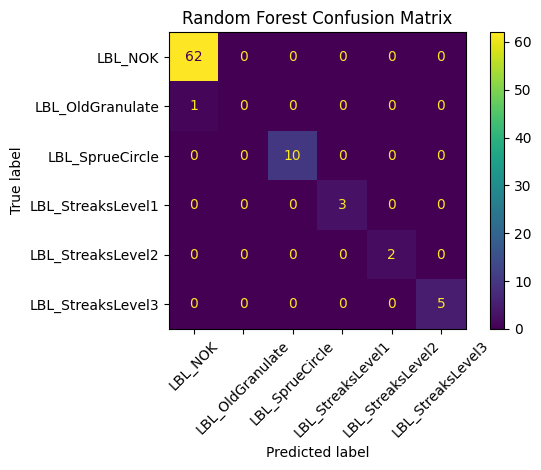

In [12]:
# Random Forest Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [18]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance.head(20)

,Feature,Importance
153,DOS_acDessicantBedCycleTime_peak,0.012391
179,DOS_acTotalWeight_max,0.011987
788,DXP_MldCavPrs1Act_kurtosis,0.010851
143,DOS_acDessicantBedCycleTime_mean,0.010344
787,DXP_MldCavPrs1Act_skew,0.009970
145,DOS_acDessicantBedCycleTime_min,0.009920
702,DXP_Inj1PrsAct_rms,0.009903
38,DOS_acComp1TotalWeight_median,0.009493
485,DXP_DriveSiePlst1TrqAct_std,0.009364
350,DRY_HT102_acTempDryair_rms,0.009049


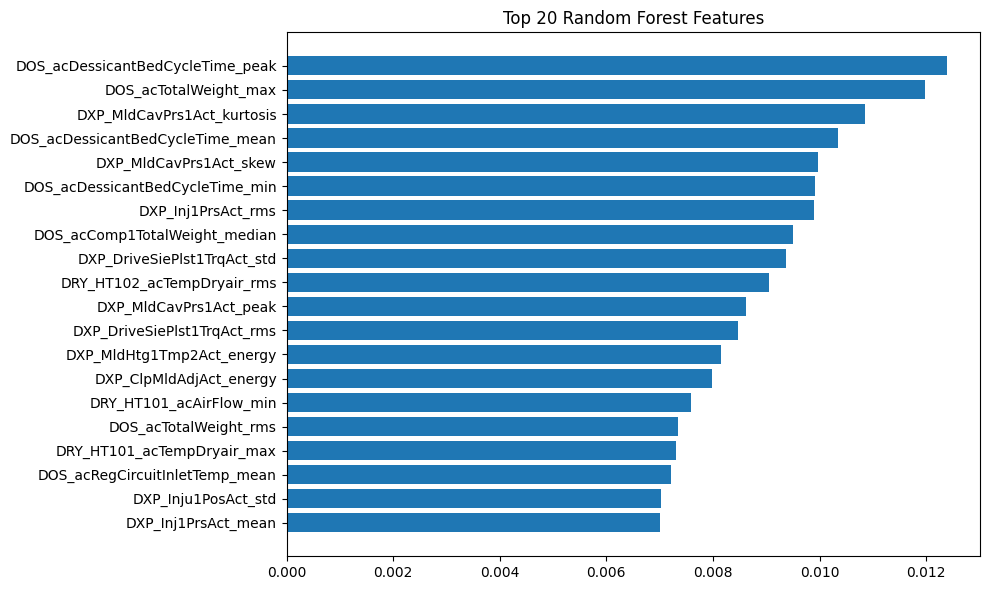

In [19]:
top20 = rf_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Random Forest Features")
plt.tight_layout()
plt.show()

In [13]:
# Train XGBoost Classifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost trained successfully")

XGBoost trained successfully


In [14]:
# Evaluate XGBoost Model

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=label_encoder.classes_
))

XGBoost Accuracy: 0.963855421686747

Classification Report:
                   precision    recall  f1-score   support

          LBL_NOK       0.95      1.00      0.98        62
 LBL_OldGranulate       0.00      0.00      0.00         1
  LBL_SprueCircle       1.00      1.00      1.00        10
LBL_StreaksLevel1       1.00      1.00      1.00         3
LBL_StreaksLevel2       1.00      0.50      0.67         2
LBL_StreaksLevel3       1.00      0.80      0.89         5

         accuracy                           0.96        83
        macro avg       0.83      0.72      0.76        83
     weighted avg       0.95      0.96      0.96        83



c:\Users\Hanna Susan Mathew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanna Susan Mathew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hanna Susan Mathew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

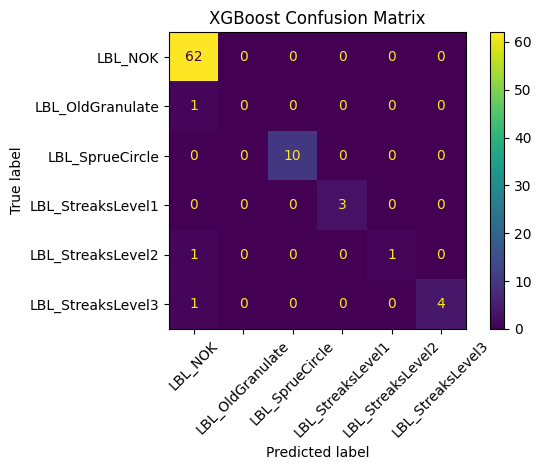

In [15]:
# XGBoost Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [20]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_importance.head(20)

,Feature,Importance
778,DXP_Inju1VelAct_energy,0.144315
17,DOS_acComp1DosRate_skew,0.063802
253,DRY_HT101_acTempReturnAir_mean,0.048357
1390,TCN_TemperatureMainLine_range,0.044578
14,DOS_acComp1DosRate_max,0.033535
143,DOS_acDessicantBedCycleTime_mean,0.032845
341,DRY_HT102_acTempDryair_mean,0.030407
844,DXP_OilTmp1Act_energy,0.030216
11,DOS_acComp1DosRate_mean,0.026299
920,DXP_Pmp1PrsAct_kurtosis,0.025681


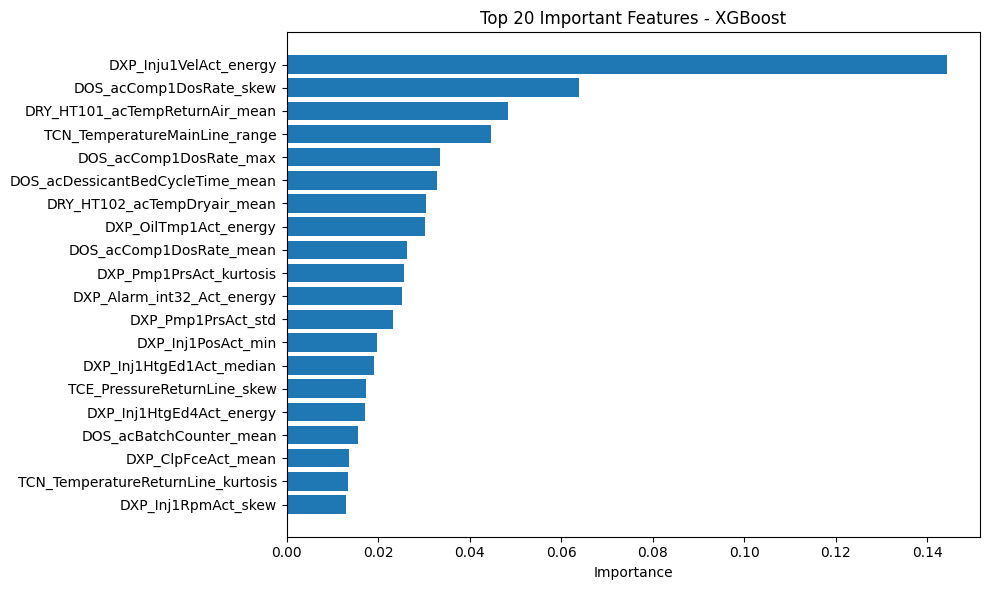

In [21]:
top20_xgb = xgb_importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20_xgb["Feature"],
    top20_xgb["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features - XGBoost")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [16]:
# Model Comparison

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, rf_pred, average="weighted", zero_division=0)
    ],
    "XGBoost": [
        accuracy_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
        recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
        f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
    ]
})

comparison

,Metric,Random Forest,XGBoost
0,Accuracy,0.987952,0.963855
1,Precision,0.976095,0.953475
2,Recall,0.987952,0.963855
3,F1-score,0.981976,0.955581


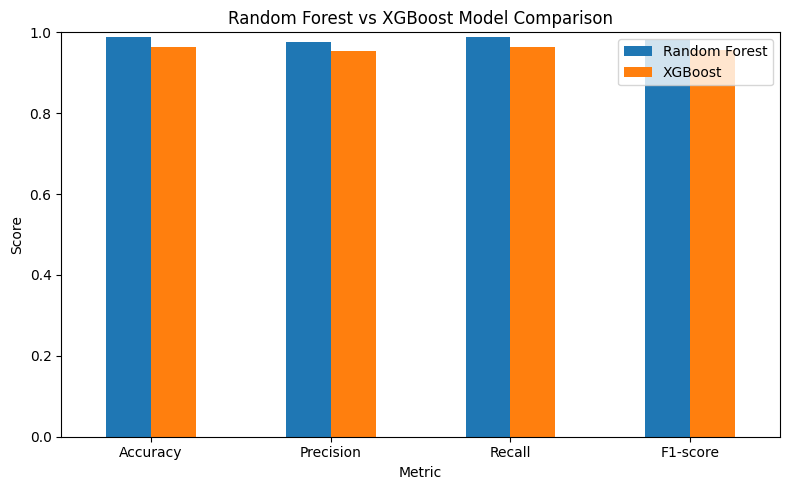

In [17]:
# Comparison Chart

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(kind="bar", figsize=(8,5))

plt.title("Random Forest vs XGBoost Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

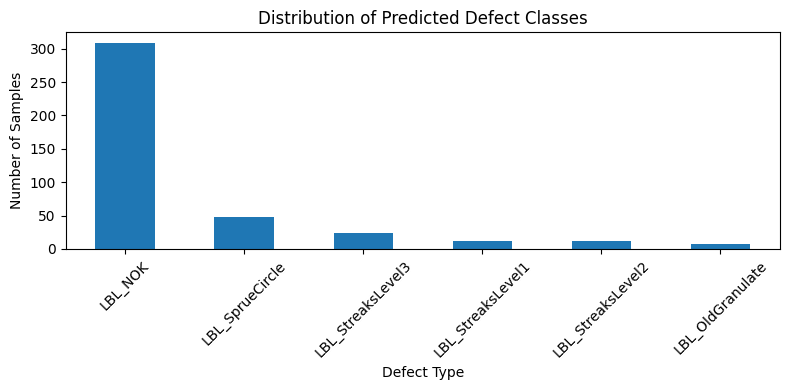

In [30]:
plt.figure(figsize=(8,4))

y.value_counts().plot(kind="bar")

plt.title("Distribution of Predicted Defect Classes")
plt.xlabel("Defect Type")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Conclusion**

Two machine learning models, Random Forest and XGBoost, were trained and evaluated using the same multiclass dataset and the same train-test split.

The models were compared using four evaluation metrics: accuracy, precision, recall, and F1-score.

The Random Forest model achieved higher performance across all evaluation metrics:

- Accuracy: 98.80%
- Precision: 97.61%
- Recall: 98.80%
- F1-score: 98.20%

In comparison, the XGBoost model achieved:

- Accuracy: 96.39%
- Precision: 95.35%
- Recall: 96.39%
- F1-score: 95.56%

Based on these results, the Random Forest model demonstrated superior classification performance for this dataset and was selected as the preferred model for injection molding defect classification.